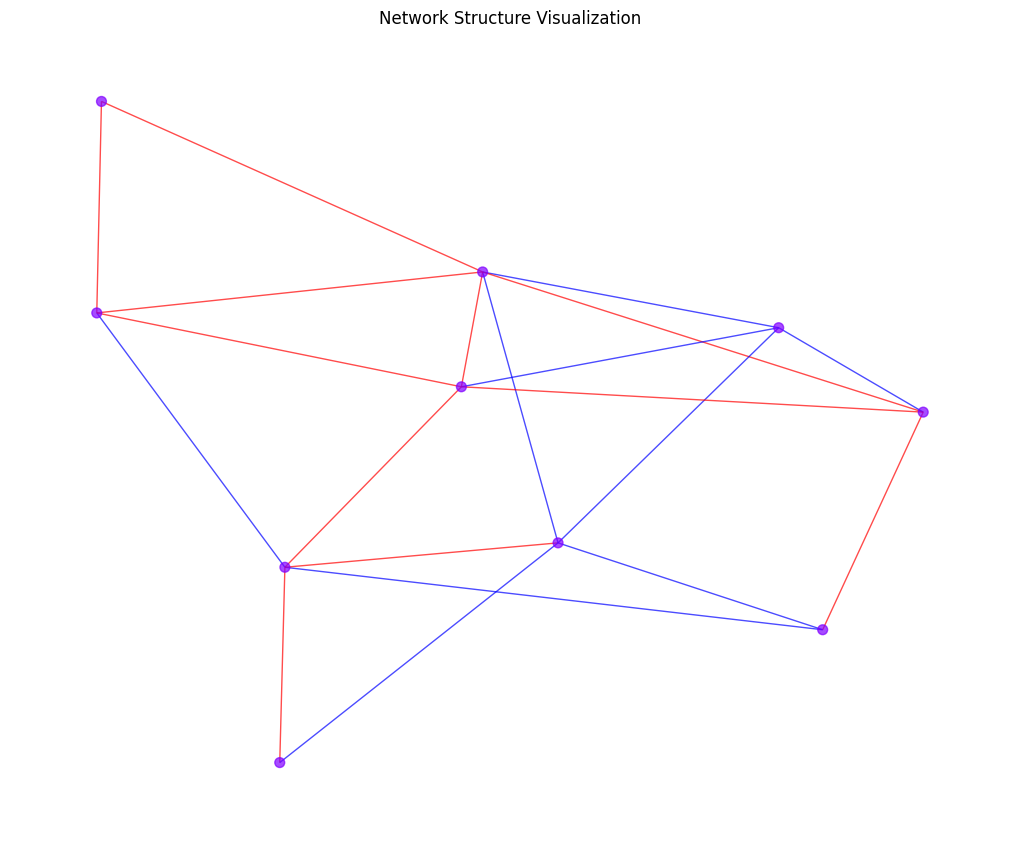

In [10]:
import networkx as nx
import matplotlib.pyplot as plt
import random

class NetworkVisualization:
    def __init__(self, num_people, num_clusters, intra_connections_per_cluster, total_inter_connections):
        self.num_people = num_people
        self.num_clusters = num_clusters
        self.intra_connections_per_cluster = intra_connections_per_cluster
        self.total_inter_connections = total_inter_connections
        self._initialize_network()

    def _initialize_network(self):
        """初始化網絡結構"""
        self.clusters = [list(range(i * (self.num_people // self.num_clusters),
                                    (i + 1) * (self.num_people // self.num_clusters)))
                         for i in range(self.num_clusters)]

        self.intra_connections = {i: set() for i in range(self.num_clusters)}
        self.inter_connections = set()

        # 產生區塊內連線
        for i in range(self.num_clusters):
            while len(self.intra_connections[i]) < self.intra_connections_per_cluster:
                src, tgt = random.sample(self.clusters[i], 2)
                self.intra_connections[i].add((src, tgt))

        # 產生區塊間連線
        while len(self.inter_connections) < self.total_inter_connections:
            src_cluster, tgt_cluster = random.sample(range(self.num_clusters), 2)
            src = random.choice(self.clusters[src_cluster])
            tgt = random.choice(self.clusters[tgt_cluster])
            self.inter_connections.add((src, tgt))

    def visualize_network(self):
        """繪製網絡結構"""
        G = nx.Graph()
        
        # 加入節點
        for cluster in self.clusters:
            G.add_nodes_from(cluster)
        
        # 加入區塊內連線 (藍色)
        intra_edges = []
        for conns in self.intra_connections.values():
            intra_edges.extend(conns)
        G.add_edges_from(intra_edges)

        # 加入區塊間連線 (紅色)
        G.add_edges_from(self.inter_connections)

        # 設定節點顏色
        cluster_colors = []
        cluster_map = {}
        for i, cluster in enumerate(self.clusters):
            for node in cluster:
                cluster_map[node] = i  # 標示該節點屬於哪個 cluster
                cluster_colors.append(i)

        # 設定邊的顏色
        edge_colors = ["blue" if edge in intra_edges else "red" for edge in G.edges()]

        # 繪圖
        plt.figure(figsize=(10, 8))
        pos = nx.spring_layout(G, seed=42)  # 使用 spring layout 排列
        nx.draw(G, pos, node_color=cluster_colors, edge_color=edge_colors,
                cmap=plt.cm.rainbow, with_labels=False, node_size=50, alpha=0.7)
        plt.title("Network Structure Visualization")
        plt.show()

# 測試可視化
network_viz = NetworkVisualization(num_people=10, num_clusters=1, intra_connections_per_cluster=20, total_inter_connections=0)
network_viz.visualize_network()


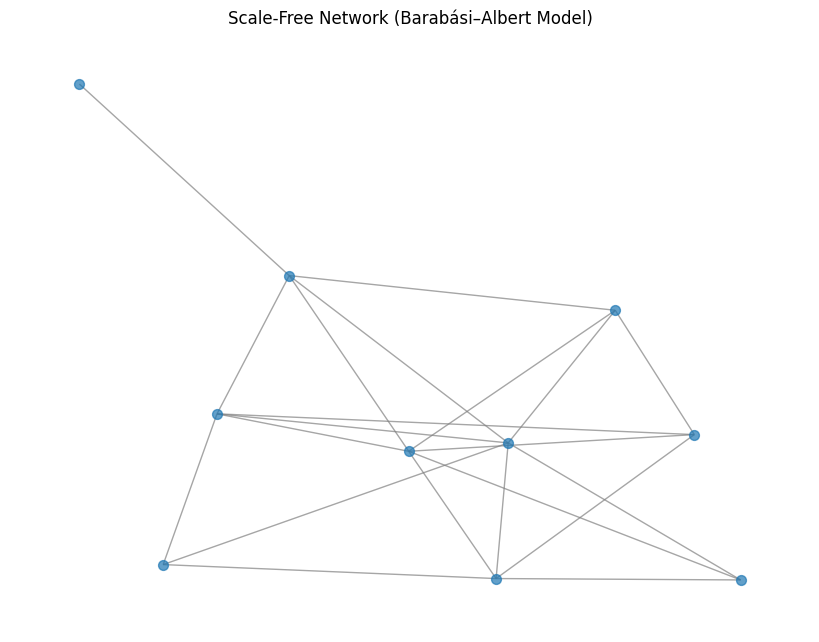

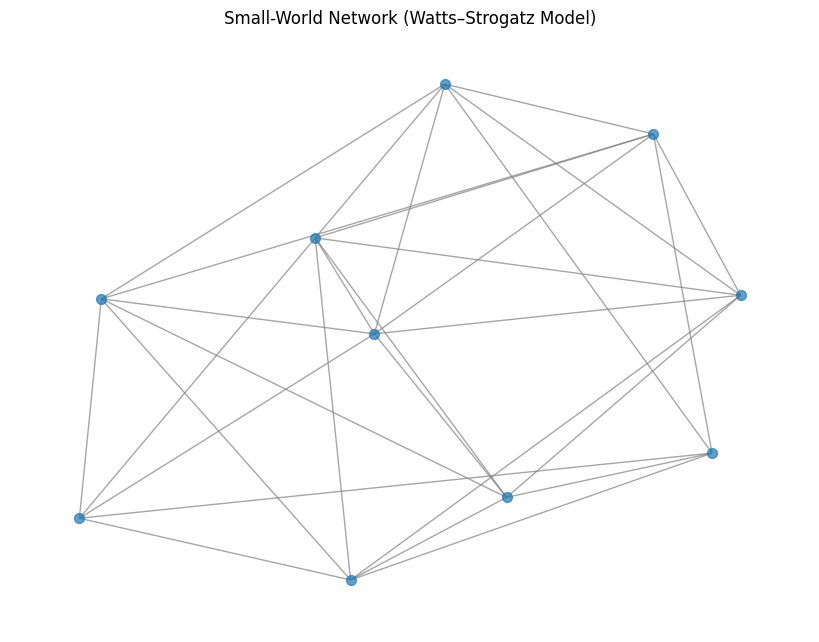

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_network(G, title):
    """可視化網絡結構"""
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42)  # 使用 spring layout 排列
    nx.draw(G, pos, with_labels=False, node_size=50, edge_color="gray", alpha=0.7)
    plt.title(title)
    plt.show()

# **生成 Scale-Free (無尺度) 網絡**
scale_free_graph = nx.barabasi_albert_graph(n=10, m=3)  # n=節點數, m=新節點連接的數量
visualize_network(scale_free_graph, "Scale-Free Network (Barabási–Albert Model)")

# **生成 Small-World (小世界) 網絡**
small_world_graph = nx.watts_strogatz_graph(n=10, k=6, p=0.1)  # k=鄰近連線數, p=重連概率
visualize_network(small_world_graph, "Small-World Network (Watts–Strogatz Model)")
